# LLM Evaluation Results Analysis

This notebook analyzes the performance of 3 LLaMA-family models across 5 prompting techniques on 32 SED puzzles.

### Models Evaluated
- LLaMA 3.3 70 - 70B parameters
- LLaMA 4 Scout 17B - 17B parameters
- LLaMA 3.1 8B - 8B parameters

### Prompting Techniques
1. Zero-Shot - Direct instruction without examples
2. Few-Shot - 5 solved examples provided
3. Chain-of-Thought (CoT) - Step-by-step reasoning
4. Self-Verify - Propose → Simulate → Verify → Revise
5. Role-Classify - Classify rule roles before solving


In [58]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Color schemes
MODEL_COLORS = {
    'LLaMA 3.3 70B': '#3498db',   # Blue
    'LLaMA 4 Scout': '#e74c3c',   # Red  
    'LLaMA 3.1 8B': '#2ecc71',    # Green
}

PROMPT_COLORS = {
    'Zero-Shot': '#1abc9c',
    'Few-Shot': '#9b59b6',
    'CoT': '#e67e22',
    'Self-Verify': '#3498db',
    'Role-Classify': '#e74c3c',
}

DIFFICULTY_COLORS = {
    'easy': '#2ecc71',
    'medium': '#f39c12',
    'hard': '#e74c3c',
}

# Model display name mapping
MODEL_DISPLAY = {
    'llama-3.3-70b-versatile': 'LLaMA 3.3 70B',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'LLaMA 4 Scout',
    'llama-3.1-8b-instant': 'LLaMA 3.1 8B',
}

PROMPT_DISPLAY = {
    'zero_shot': 'Zero-Shot',
    'few_shot': 'Few-Shot',
    'cot': 'CoT',
    'self_verify': 'Self-Verify',
    'role_classify': 'Role-Classify',
}


In [59]:
# Load all result files
results_dir = Path('../results')

models = ['llama-3.3-70b', 'llama-4-scout', 'llama-3.1-8b']
prompt_types = ['zero_shot', 'few_shot', 'cot', 'self_verify', 'role_classify']

# Load all summary files
all_results = {}
detailed_results = []

for model in models:
    all_results[model] = {}
    for pt in prompt_types:
        summary_file = results_dir / f"{model}_{pt}_summary.json"
        if summary_file.exists():
            with open(summary_file) as f:
                data = json.load(f)
                all_results[model][pt] = {
                    'model': data['model'],
                    'accuracy': data['accuracy'],
                    'correct': data['correct'],
                    'total': data['total_puzzles'],
                    'parsing_errors': data['parsing_errors'],
                    'invalid_solutions': data['invalid_solutions'],
                    'api_errors': data['api_errors'],
                    'avg_response_time': data['avg_response_time'],
                }
                # Store detailed results for per-puzzle analysis
                for result in data.get('results', []):
                    detailed_results.append({
                        'model': model,
                        'prompt_type': pt,
                        'problem_id': result['problem_id'],
                        'is_correct': result['is_correct'],
                        'error_type': result.get('error_type'),
                        'response_time': result.get('response_time', 0),
                    })

# Load metadata for difficulty info
with open('../data/metadata.json') as f:
    metadata = json.load(f)
metadata_dict = {m['problem_id']: m for m in metadata}

# Create detailed DataFrame
df_detailed = pd.DataFrame(detailed_results)

# Add difficulty info
df_detailed['difficulty'] = df_detailed['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown')
)
df_detailed['generator'] = df_detailed['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('generator', 'unknown')
)

print(f"Loaded results for {len(models)} models × {len(prompt_types)} prompt types")
print(f"Total evaluations: {len(df_detailed)}")


Loaded results for 3 models × 5 prompt types
Total evaluations: 480


In [60]:
# Build comprehensive comparison DataFrame
comparison_data = []

model_name_map = {
    'llama-3.3-70b': 'LLaMA 3.3 70B',
    'llama-4-scout': 'LLaMA 4 Scout',
    'llama-3.1-8b': 'LLaMA 3.1 8B',
}

for model in models:
    for pt in prompt_types:
        if pt in all_results[model]:
            data = all_results[model][pt]
            comparison_data.append({
                'Model': model_name_map[model],
                'Prompt Type': PROMPT_DISPLAY[pt],
                'Accuracy (%)': data['accuracy'] * 100,
                'Correct': data['correct'],
                'Total': data['total'],
                'Parsing Errors': data['parsing_errors'],
                'Invalid Solutions': data['invalid_solutions'],
                'API Errors': data['api_errors'],
                'Avg Response Time (s)': data['avg_response_time'],
                'model_key': model,
                'prompt_key': pt,
            })

df_comparison = pd.DataFrame(comparison_data)

# Display summary table
print("="*80)
print("OVERALL PERFORMANCE SUMMARY")
print("="*80)

pivot_display = df_comparison.pivot_table(
    values='Accuracy (%)', 
    index='Model', 
    columns='Prompt Type',
    aggfunc='mean'
).round(1)

# Reorder columns
col_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
pivot_display = pivot_display[[c for c in col_order if c in pivot_display.columns]]

print("\n📊 Accuracy by Model and Prompt Type (%):\n")
print(pivot_display.to_string())

# Best combinations
print("\n" + "="*80)
print("🏆 TOP 5 MODEL-PROMPT COMBINATIONS")
print("="*80)
top5 = df_comparison.nlargest(5, 'Accuracy (%)')
for i, row in top5.iterrows():
    print(f"  {row['Model']} + {row['Prompt Type']}: {row['Accuracy (%)']:.1f}% ({row['Correct']}/{row['Total']})")


OVERALL PERFORMANCE SUMMARY

📊 Accuracy by Model and Prompt Type (%):

Prompt Type    Zero-Shot  Few-Shot   CoT  Self-Verify  Role-Classify
Model                                                               
LLaMA 3.1 8B         6.2       9.4  15.6          6.2           18.8
LLaMA 3.3 70B       31.2      34.4  31.2         31.2           28.1
LLaMA 4 Scout       37.5      43.8  37.5         25.0           34.4

🏆 TOP 5 MODEL-PROMPT COMBINATIONS
  LLaMA 4 Scout + Few-Shot: 43.8% (14/32)
  LLaMA 4 Scout + Zero-Shot: 37.5% (12/32)
  LLaMA 4 Scout + CoT: 37.5% (12/32)
  LLaMA 3.3 70B + Few-Shot: 34.4% (11/32)
  LLaMA 4 Scout + Role-Classify: 34.4% (11/32)


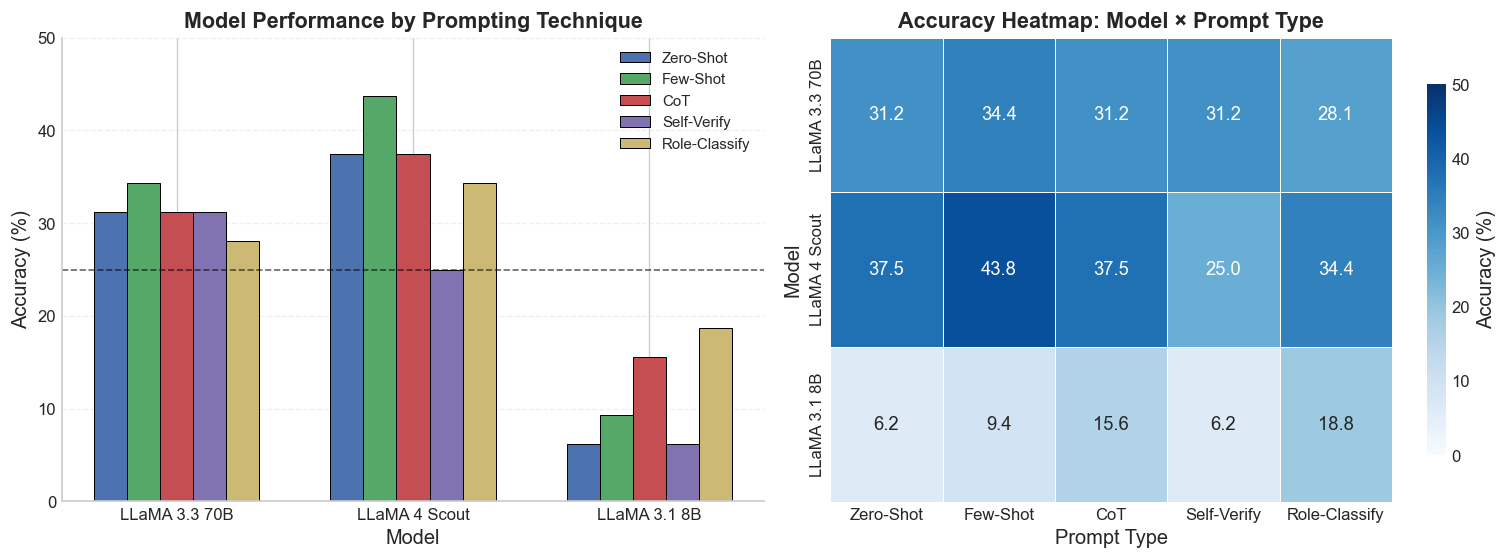

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table
pivot_accuracy = df_comparison.pivot_table(
    values='Accuracy (%)',
    index='Model',
    columns='Prompt Type',
    aggfunc='mean'
)

# Order rows / columns
col_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
row_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']

pivot_accuracy = pivot_accuracy[[c for c in col_order if c in pivot_accuracy.columns]]
pivot_accuracy = pivot_accuracy.reindex([r for r in row_order if r in pivot_accuracy.index])

# Classic muted palette (prompt types)
PROMPT_COLORS = [
    '#4C72B0',  # blue
    '#55A868',  # green
    '#C44E52',  # red
    '#8172B2',  # purple
    '#CCB974'   # mustard
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# -------------------------------------------------
# Left: Grouped bar chart
# -------------------------------------------------
ax1 = axes[0]
x = np.arange(len(pivot_accuracy.index))
width = 0.14

for i, pt in enumerate(pivot_accuracy.columns):
    values = pivot_accuracy[pt].values
    ax1.bar(
        x + i * width,
        values,
        width,
        label=pt,
        color=PROMPT_COLORS[i],
        edgecolor='black',
        linewidth=0.6
    )

ax1.axhline(25, color='black', linestyle='--', linewidth=1, alpha=0.6)

ax1.set_xticks(x + width * (len(pivot_accuracy.columns) - 1) / 2)
ax1.set_xticklabels(pivot_accuracy.index)
ax1.set_ylim(0, 50)

ax1.set_title("Model Performance by Prompting Technique", fontsize=13)
ax1.set_xlabel("Model")
ax1.set_ylabel("Accuracy (%)")
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.legend(fontsize=9, frameon=False)

# -------------------------------------------------
# Right: Heatmap (clean, neutral)
# -------------------------------------------------
ax2 = axes[1]
sns.heatmap(
    pivot_accuracy,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=50,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
    ax=ax2
)

ax2.set_title("Accuracy Heatmap: Model × Prompt Type", fontsize=13)
ax2.set_xlabel("Prompt Type")
ax2.set_ylabel("Model")

plt.tight_layout()
plt.savefig(
    "../results/model_prompt_comparison.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


### Performance Analysis
Comparative evaluation of multiple prompting strategies across different LLM architectures.

**Left (Grouped Bar Chart):**
- Shows mean accuracy (%) for each *prompting technique* across models.
- A dashed horizontal line at 25% indicates the random or baseline performance level.
- While advanced prompting methods (e.g., *CoT*, *Self-Verify*) often increase apparent progress, gains are model-dependent and suggesting verbosity and local reasoning do not translate to semantic correctness. 

**Right (Heatmap):**
- Larger models benefiting more from structured prompting.
 - Smaller models showing limited or noisy gains despite increased prompt complexity.

Takeaway:  Improvements from sophisticated prompting techniques do not scale uniformly across models. This reinforces the need for **controlled evaluation**, as higher prompt complexity can inflate intermediate metrics without guaranteeing true semantic correctness.


## Performance by Difficulty Level


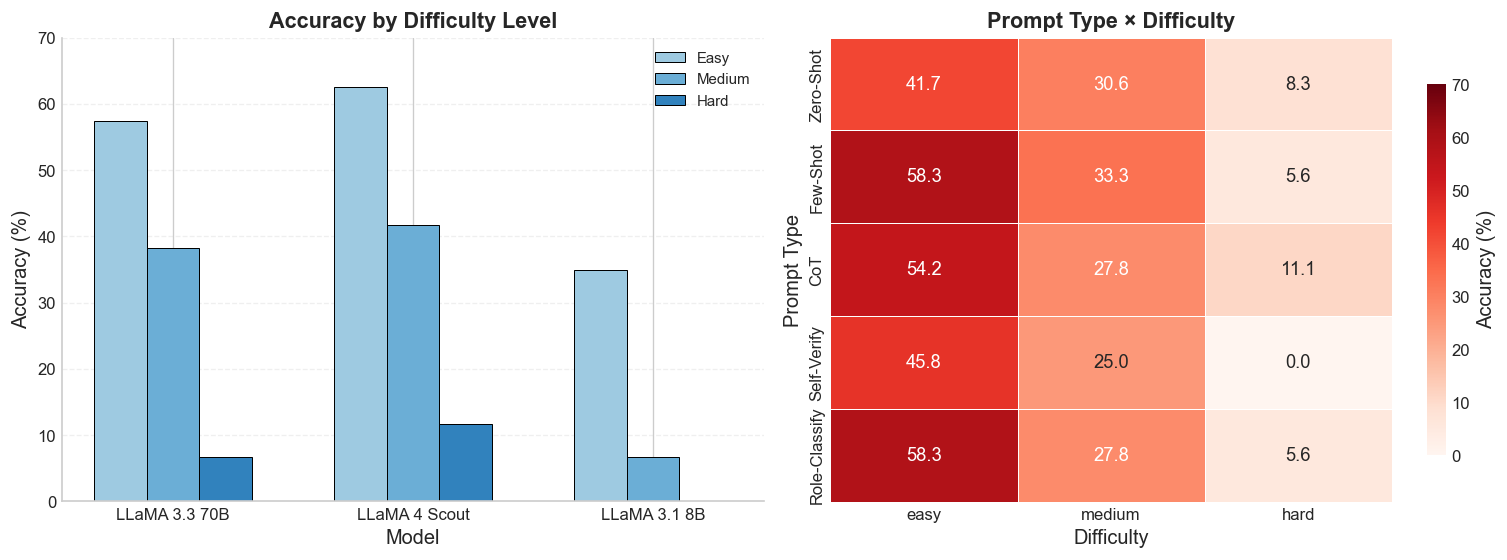

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
difficulty_perf = df_detailed.groupby(['model', 'difficulty']).agg(
    correct=('is_correct', 'sum'),
    total=('is_correct', 'count')
).reset_index()

difficulty_perf['accuracy'] = difficulty_perf['correct'] / difficulty_perf['total'] * 100
difficulty_perf['model_display'] = difficulty_perf['model'].map(model_name_map)

# Pivot for model × difficulty
pivot_diff = difficulty_perf.pivot(
    index='model_display',
    columns='difficulty',
    values='accuracy'
)

diff_order = ['easy', 'medium', 'hard']
model_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']

pivot_diff = pivot_diff[[d for d in diff_order if d in pivot_diff.columns]]
pivot_diff = pivot_diff.reindex([m for m in model_order if m in pivot_diff.index])

# Pivot for prompt × difficulty
prompt_diff = df_detailed.groupby(['prompt_type', 'difficulty']).agg(
    accuracy=('is_correct', 'mean')
).reset_index()

prompt_diff['accuracy'] *= 100
prompt_diff['prompt_display'] = prompt_diff['prompt_type'].map(PROMPT_DISPLAY)

pivot_prompt_diff = prompt_diff.pivot(
    index='prompt_display',
    columns='difficulty',
    values='accuracy'
)

prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
pivot_prompt_diff = pivot_prompt_diff[[d for d in diff_order if d in pivot_prompt_diff.columns]]
pivot_prompt_diff = pivot_prompt_diff.reindex([p for p in prompt_order if p in pivot_prompt_diff.index])

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Classic colors (muted, print-safe)
DIFF_COLORS = {
    'easy':   '#9ECAE1',
    'medium': '#6BAED6',
    'hard':   '#3182BD'
}

# -----------------------------
# Left: Grouped bar chart
# -----------------------------
ax1 = axes[0]
x = np.arange(len(pivot_diff.index))
width = 0.22

for i, diff in enumerate(pivot_diff.columns):
    ax1.bar(
        x + i * width,
        pivot_diff[diff].values,
        width,
        label=diff.capitalize(),
        color=DIFF_COLORS[diff],
        edgecolor='black',
        linewidth=0.6
    )

ax1.set_xticks(x + width)
ax1.set_xticklabels(pivot_diff.index)
ax1.set_ylim(0, 70)

ax1.set_title("Accuracy by Difficulty Level", fontsize=13)
ax1.set_xlabel("Model")
ax1.set_ylabel("Accuracy (%)")
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.legend(fontsize=9, frameon=False)

# -----------------------------
# Right: Heatmap (neutral)
# -----------------------------
ax2 = axes[1]
sns.heatmap(
    pivot_prompt_diff,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    vmin=0,
    vmax=70,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
    ax=ax2
)

ax2.set_title("Prompt Type × Difficulty", fontsize=13)
ax2.set_xlabel("Difficulty")
ax2.set_ylabel("Prompt Type")

plt.tight_layout()
plt.savefig(
    "../results/difficulty_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


## Prompting Technique Analysis


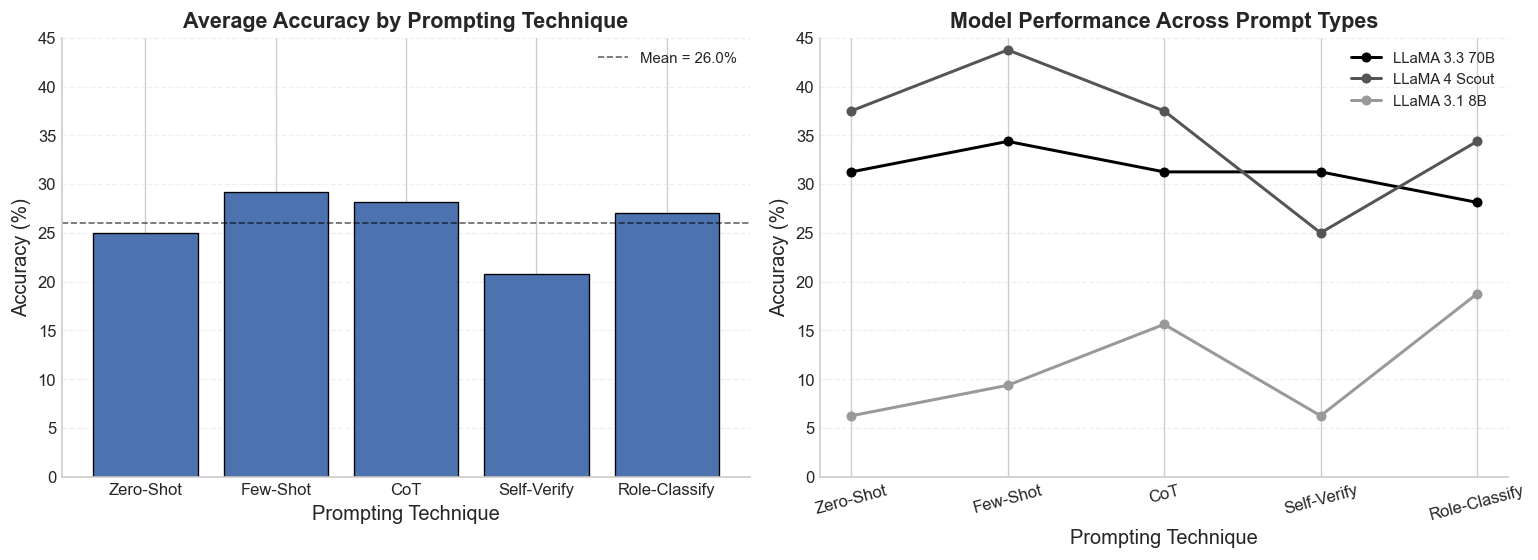

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Order
prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
model_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']

# Average accuracy by prompt
prompt_avg = (
    df_comparison
    .groupby('Prompt Type')['Accuracy (%)']
    .mean()
    .reindex(prompt_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# -------------------------------------------------
# Left: Average accuracy by prompt type
# -------------------------------------------------
ax1 = axes[0]

ax1.bar(
    prompt_avg.index,
    prompt_avg.values,
    color='#4C72B0',          # single muted blue
    edgecolor='black',
    linewidth=0.8
)

ax1.axhline(
    prompt_avg.mean(),
    color='black',
    linestyle='--',
    linewidth=1,
    alpha=0.6,
    label=f"Mean = {prompt_avg.mean():.1f}%"
)

ax1.set_title("Average Accuracy by Prompting Technique", fontsize=13)
ax1.set_xlabel("Prompting Technique")
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.legend(frameon=False, fontsize=9)

# -------------------------------------------------
# Right: Prompt effectiveness by model (line plot)
# -------------------------------------------------
ax2 = axes[1]

LINE_COLORS = ['black', '#555555', '#999999']  # grayscale-safe

for model, color in zip(model_order, LINE_COLORS):
    model_data = (
        df_comparison[df_comparison['Model'] == model]
        .set_index('Prompt Type')
        .reindex(prompt_order)
    )

    ax2.plot(
        model_data.index,
        model_data['Accuracy (%)'],
        marker='o',
        markersize=5,
        linewidth=1.8,
        color=color,
        label=model
    )

ax2.set_title("Model Performance Across Prompt Types", fontsize=13)
ax2.set_xlabel("Prompting Technique")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 45)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.legend(frameon=False, fontsize=9)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(
    "../results/prompt_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


## Error Analysis


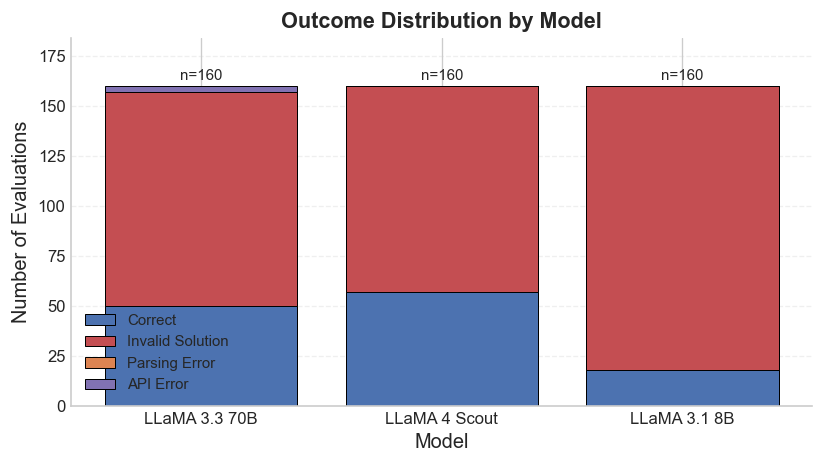


Error Analysis Summary:
  Total evaluations: 480
  Correct: 125 (26.0%)
  Invalid Solution: 352 (73.3%)
  Parsing Error: 0 (0.0%)
  API Error: 3 (0.6%)


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Aggregate error data
# -----------------------------
error_data = []

for model in models:
    model_name = model_name_map[model]

    totals = {
        'Correct': 0,
        'Invalid Solution': 0,
        'Parsing Error': 0,
        'API Error': 0,
        'Total': 0
    }

    for pt in prompt_types:
        if pt in all_results[model]:
            d = all_results[model][pt]
            totals['Correct'] += d['correct']
            totals['Invalid Solution'] += d['invalid_solutions']
            totals['Parsing Error'] += d['parsing_errors']
            totals['API Error'] += d['api_errors']
            totals['Total'] += d['total']

    error_data.append({
        'Model': model_name,
        **totals
    })

df_errors = pd.DataFrame(error_data).set_index('Model')

# Only outcome columns
outcomes = ['Correct', 'Invalid Solution', 'Parsing Error', 'API Error']
df_plot = df_errors[outcomes]

# -----------------------------
# Plot: stacked bar chart
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

OUTCOME_COLORS = {
    'Correct': '#4C72B0',
    'Invalid Solution': '#C44E52',
    'Parsing Error': '#DD8452',
    'API Error': '#8172B2'
}

bottom = np.zeros(len(df_plot))

for outcome in outcomes:
    ax.bar(
        df_plot.index,
        df_plot[outcome],
        bottom=bottom,
        label=outcome,
        color=OUTCOME_COLORS[outcome],
        edgecolor='black',
        linewidth=0.6
    )
    bottom += df_plot[outcome].values

# Add headroom BEFORE rendering
y_max = df_plot.sum(axis=1).max()
ax.set_ylim(0, y_max * 1.15)

# Total labels
for i, model in enumerate(df_plot.index):
    total = df_plot.loc[model].sum()
    ax.text(i, total + y_max * 0.02, f'n={int(total)}',
            ha='center', fontsize=9)

ax.set_title("Outcome Distribution by Model", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Number of Evaluations")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "../results/error_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# -----------------------------
# Summary (text only)
# -----------------------------
total_evals = df_plot.sum().sum()

print("\nError Analysis Summary:")
print(f"  Total evaluations: {int(total_evals)}")

for outcome in outcomes:
    count = df_plot[outcome].sum()
    print(f"  {outcome}: {int(count)} ({count / total_evals * 100:.1f}%)")


## 7. Response Time Analysis


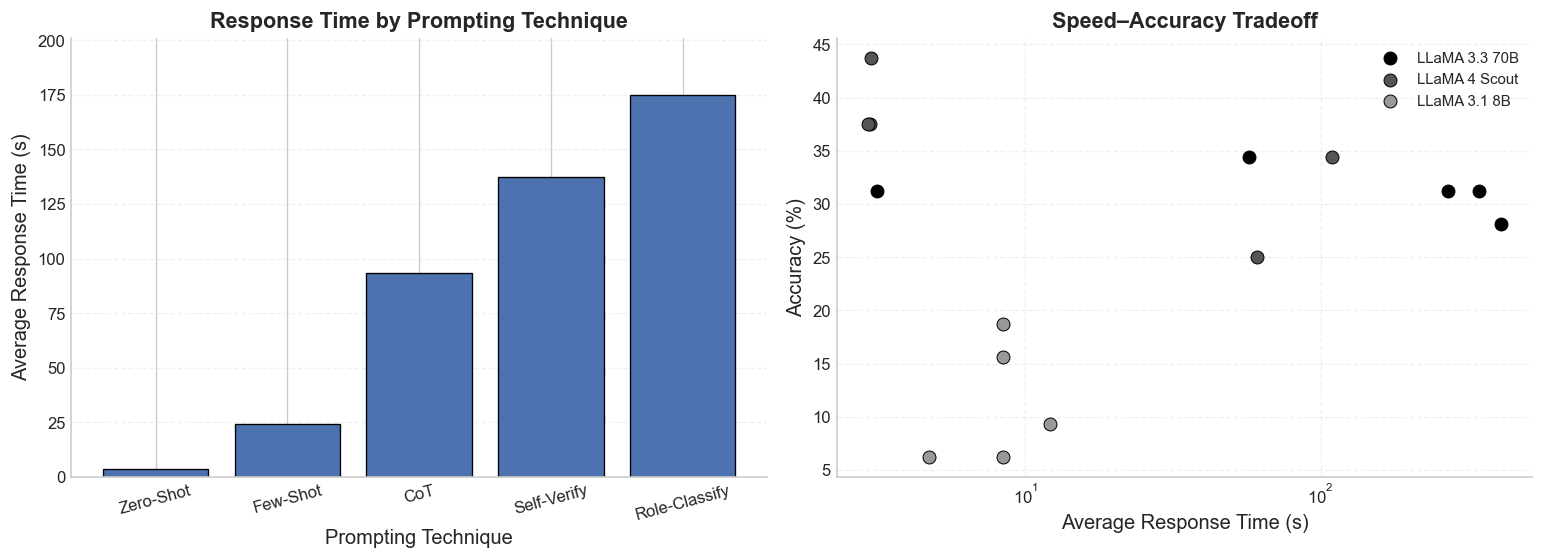

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Order
prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
model_order = ['LLaMA 3.3 70B', 'LLaMA 4 Scout', 'LLaMA 3.1 8B']

# -----------------------------
# Aggregate response time
# -----------------------------
time_by_prompt = (
    df_comparison
    .groupby('Prompt Type')['Avg Response Time (s)']
    .mean()
    .reindex(prompt_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# -----------------------------
# Left: Response time by prompt
# -----------------------------
ax1 = axes[0]

ax1.bar(
    time_by_prompt.index,
    time_by_prompt.values,
    color='#4C72B0',          # single muted blue
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title("Response Time by Prompting Technique", fontsize=13)
ax1.set_xlabel("Prompting Technique")
ax1.set_ylabel("Average Response Time (s)")
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.tick_params(axis='x', rotation=15)

# Add headroom
y_max = time_by_prompt.max()
ax1.set_ylim(0, y_max * 1.15)

# -----------------------------
# Right: Speed vs accuracy tradeoff
# -----------------------------
ax2 = axes[1]

LINE_COLORS = ['black', '#555555', '#999999']  # grayscale-safe

for model, color in zip(model_order, LINE_COLORS):
    model_data = df_comparison[df_comparison['Model'] == model]

    ax2.scatter(
        model_data['Avg Response Time (s)'],
        model_data['Accuracy (%)'],
        s=60,
        color=color,
        edgecolor='black',
        linewidth=0.6,
        label=model
    )

ax2.set_title("Speed–Accuracy Tradeoff", fontsize=13)
ax2.set_xlabel("Average Response Time (s)")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xscale('log')   # justified due to large time spread
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    "../results/response_time_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


Average response time varies significantly across prompting techniques, indicating a non-trivial computational cost for more structured prompts. The speed–accuracy tradeoff differs across models, implying that latency costs of prompting strategies are not uniform across model scales.

## Per-Puzzle Success Analysis


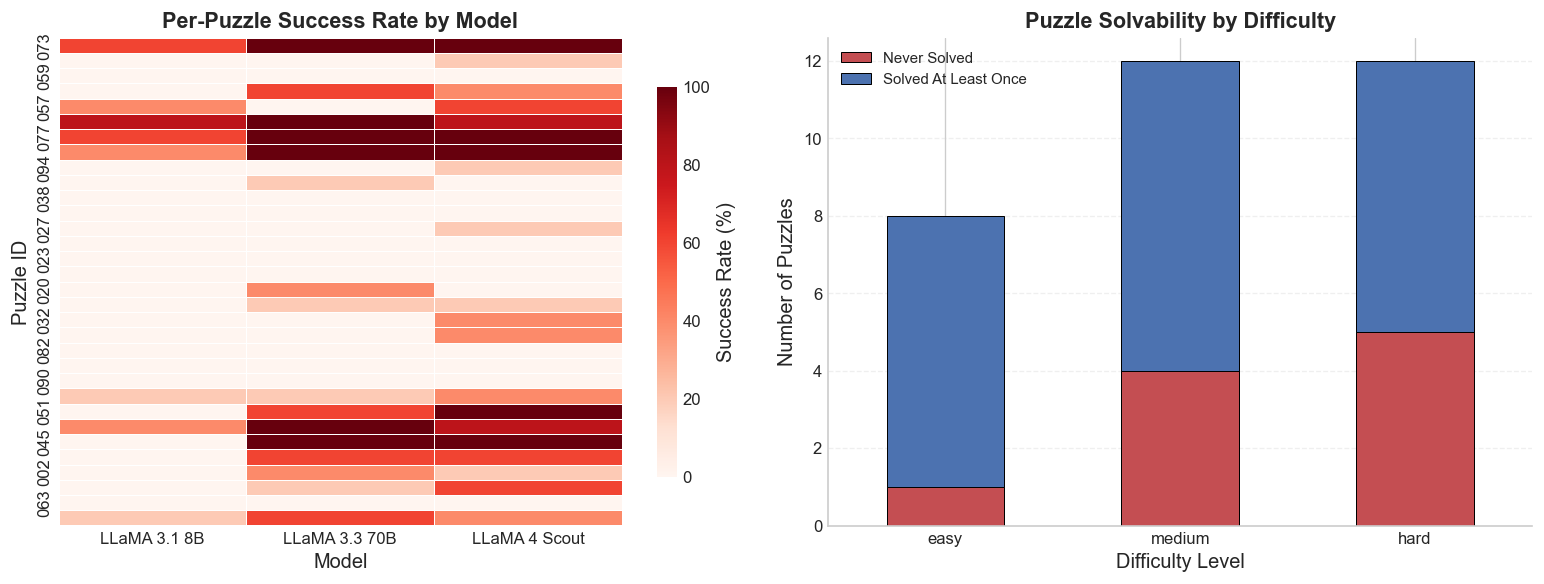


Puzzle Difficulty Insights:

  Easiest puzzles:
    • 073 (easy): 86.7%
    • 074 (easy): 86.7%
    • 077 (easy): 86.7%

  Hardest puzzles:
    • 022 (hard): 0.0%
    • 023 (hard): 0.0%
    • 024 (hard): 0.0%


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Per-puzzle success rates
# -----------------------------
puzzle_success = df_detailed.groupby(['problem_id', 'model']).agg(
    times_correct=('is_correct', 'sum'),
    times_tested=('is_correct', 'count')
).reset_index()

puzzle_success['success_rate'] = (
    puzzle_success['times_correct'] / puzzle_success['times_tested'] * 100
)

# Pivot: puzzles × models
puzzle_pivot = puzzle_success.pivot(
    index='problem_id',
    columns='model',
    values='success_rate'
).fillna(0)

puzzle_pivot.columns = [model_name_map[m] for m in puzzle_pivot.columns]

# Attach difficulty metadata
puzzle_pivot['difficulty'] = puzzle_pivot.index.map(
    lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown')
)

# Sort by difficulty only (no ID leakage)
puzzle_pivot = puzzle_pivot.sort_values('difficulty')

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------------------------------
# Left: Per-puzzle success heatmap (neutral)
# -------------------------------------------------
ax1 = axes[0]

heatmap_data = puzzle_pivot.drop(columns='difficulty')

sns.heatmap(
    heatmap_data,
    cmap='Reds',
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Success Rate (%)', 'shrink': 0.8},
    ax=ax1
)

ax1.set_title("Per-Puzzle Success Rate by Model", fontsize=13)
ax1.set_xlabel("Model")
ax1.set_ylabel("Puzzle ID")

# -------------------------------------------------
# Right: Puzzle solvability by difficulty
# -------------------------------------------------
ax2 = axes[1]

# Solved at least once by any model
puzzle_solvability = df_detailed.groupby('problem_id')['is_correct'].any().reset_index()

puzzle_solvability['difficulty'] = puzzle_solvability['problem_id'].map(
    lambda x: metadata_dict.get(x, {}).get('difficulty_level', 'unknown')
)

diff_summary = (
    puzzle_solvability
    .groupby(['difficulty', 'is_correct'])
    .size()
    .unstack(fill_value=0)
)

diff_summary.columns = ['Never Solved', 'Solved At Least Once']
diff_summary = diff_summary.reindex(['easy', 'medium', 'hard'])

# Stacked bar (print-safe colors)
diff_summary.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#C44E52', '#4C72B0'],
    edgecolor='black',
    linewidth=0.6
)

ax2.set_title("Puzzle Solvability by Difficulty", fontsize=13)
ax2.set_xlabel("Difficulty Level")
ax2.set_ylabel("Number of Puzzles")
ax2.legend(frameon=False, fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(
    "../results/puzzle_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# -----------------------------
# Text-only difficulty extremes
# -----------------------------
overall_success = df_detailed.groupby('problem_id')['is_correct'].mean() * 100

print("\nPuzzle Difficulty Insights:")

print("\n  Easiest puzzles:")
for pid, rate in overall_success.nlargest(3).items():
    diff = metadata_dict.get(pid, {}).get('difficulty_level', '?')
    print(f"    • {pid} ({diff}): {rate:.1f}%")

print("\n  Hardest puzzles:")
for pid, rate in overall_success.nsmallest(3).items():
    diff = metadata_dict.get(pid, {}).get('difficulty_level', '?')
    print(f"    • {pid} ({diff}): {rate:.1f}%")


No single model dominates across all puzzles; success varies systematically across problem instances.
A subset of hard puzzles remains unsolved by all models across all prompting strategies, indicating genuine reasoning bottlenecks rather than prompting failure.


## Findings 

Across **480 evaluations** on a **32-puzzle test set**, overall accuracy remains low (**26%**), indicating that the benchmark poses a substantial challenge for current LLMs.

**Model scale helps, but not monotonically.**  
LLaMA-4 Scout (17B) achieves the highest average accuracy (35.6%), outperforming the larger LLaMA-3.3-70B in several settings, while the 8B model struggles on complex instances. This suggests that *architectural and training differences matter as much as raw parameter count*.

**Prompting provides limited but non-trivial gains.**  
Few-shot prompting performs best on average, but improvements over zero-shot are modest. More elaborate strategies (e.g., self-verification) incur substantial latency without consistent accuracy gains, highlighting diminishing returns from prompt complexity.

**Difficulty is the dominant factor.**  
Accuracy drops sharply from **easy (51.7%)** to **hard (6.1%)**, indicating that failures are driven primarily by multi-step reasoning demands rather than surface understanding.

**Errors are structured, not random.**  
Most failures arise from *semantically invalid solutions* rather than formatting or API errors. Self-verification does not reliably detect these failures, suggesting weak internal consistency checks.

Overall, the results indicate that **prompt engineering alone is insufficient** to overcome reasoning bottlenecks on this benchmark. Improvements likely require **stronger internal planning and error detection mechanisms**, not longer or more complex prompts.


In [67]:
# Export comprehensive summary to CSV
summary_export = df_comparison[['Model', 'Prompt Type', 'Accuracy (%)', 'Correct', 'Total', 
                                'Invalid Solutions', 'API Errors', 'Avg Response Time (s)']]
summary_export.to_csv('../results/evaluation_summary.csv', index=False)

# Export detailed results
df_detailed_export = df_detailed.copy()
df_detailed_export['model_display'] = df_detailed_export['model'].map(model_name_map)
df_detailed_export['prompt_display'] = df_detailed_export['prompt_type'].map(PROMPT_DISPLAY)
df_detailed_export.to_csv('../results/evaluation_detailed.csv', index=False)

print("  • results/evaluation_summary.csv")
print("  • results/evaluation_detailed.csv")
print("  • All visualization PNGs in results/")


  • results/evaluation_summary.csv
  • results/evaluation_detailed.csv
  • All visualization PNGs in results/
